# Phase 6: Gene-Level Train/Validation/Test Split

**This is the most critical step in our pipeline.**

### Why gene-level split?
Variants in the same gene share similar features (sequence context,
conservation patterns, protein structure). A random split would leak
information from training to test data, inflating results by 5-15%.

### Our approach:
- All variants from one gene go to the SAME split
- No gene appears in more than one split
- 70% train / 15% validation / 15% test


In [1]:
import pandas as pd

train = pd.read_parquet('../data/splits/train.parquet')
val = pd.read_parquet('../data/splits/val.parquet')
test = pd.read_parquet('../data/splits/test.parquet')

print('=' * 70)
print('GENE-LEVEL DATA SPLIT RESULTS')
print('=' * 70)
print(f"{'':>15} {'Rows':>10} {'Genes':>8} {'Pathogenic':>12} {'Benign':>10} {'Path%':>8}")
print('-' * 70)
for name, data in [('Train', train), ('Validation', val), ('Test', test)]:
    n = len(data)
    g = data['gene'].nunique()
    p = (data['label']==1).sum()
    b = (data['label']==0).sum()
    r = (data['label']==1).mean() * 100
    print(f"{name:>15} {n:>10,} {g:>8,} {p:>12,} {b:>10,} {r:>7.1f}%")
print('-' * 70)
total = len(train) + len(val) + len(test)
print(f"{'Total':>15} {total:>10,}")


GENE-LEVEL DATA SPLIT RESULTS
                      Rows    Genes   Pathogenic     Benign    Path%
----------------------------------------------------------------------
          Train    195,124   10,961       91,329    103,795    46.8%
     Validation     43,005    2,349       19,062     23,943    44.3%
           Test     45,263    2,349       22,463     22,800    49.6%
----------------------------------------------------------------------
          Total    283,392


## Overlap Verification (Zero Tolerance)


In [2]:
# Verify zero gene overlap
train_genes = set(train['gene'].unique())
val_genes = set(val['gene'].unique())
test_genes = set(test['gene'].unique())

overlap_tv = len(train_genes & val_genes)
overlap_tt = len(train_genes & test_genes)
overlap_vt = len(val_genes & test_genes)

print('Gene Overlap Check:')
print(f'  Train-Validation overlap:  {overlap_tv} genes')
print(f'  Train-Test overlap:        {overlap_tt} genes')
print(f'  Validation-Test overlap:   {overlap_vt} genes')
print()
if overlap_tv == 0 and overlap_tt == 0 and overlap_vt == 0:
    print('PASSED: Zero overlap between all splits')
    print('No data leakage is possible.')
else:
    print('FAILED: Overlap detected!')


Gene Overlap Check:
  Train-Validation overlap:  0 genes
  Train-Test overlap:        0 genes
  Validation-Test overlap:   0 genes

PASSED: Zero overlap between all splits
No data leakage is possible.


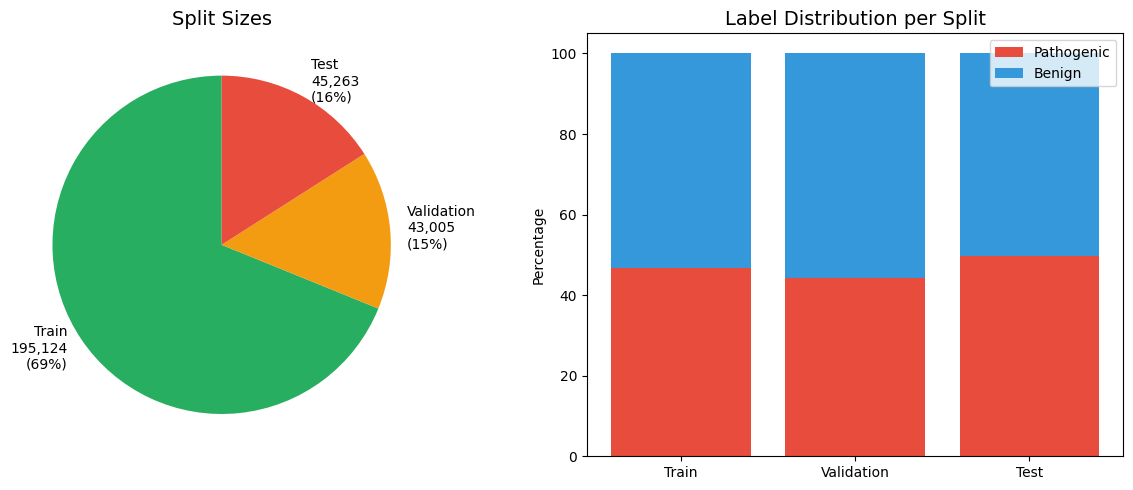

In [3]:
# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Split sizes
sizes = [len(train), len(val), len(test)]
labels = [f'Train\n{len(train):,}\n({len(train)/total*100:.0f}%)',
          f'Validation\n{len(val):,}\n({len(val)/total*100:.0f}%)',
          f'Test\n{len(test):,}\n({len(test)/total*100:.0f}%)']
colors = ['#27ae60', '#f39c12', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='', startangle=90)
axes[0].set_title('Split Sizes', fontsize=14)

# Label distribution per split
x = ['Train', 'Validation', 'Test']
path_pcts = [(train['label']==1).mean()*100,
             (val['label']==1).mean()*100,
             (test['label']==1).mean()*100]
ben_pcts = [100-p for p in path_pcts]
axes[1].bar(x, path_pcts, color='#e74c3c', label='Pathogenic')
axes[1].bar(x, ben_pcts, bottom=path_pcts, color='#3498db', label='Benign')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Label Distribution per Split', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/data_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

- Data is split at the **gene level** to prevent data leakage
- **Zero overlap** verified between all splits
- Label distribution is consistent across splits (~47% pathogenic)
- Data is ready for model training


In [4]:
train.head().T



,0,1,2,3,4
chr,20,10,10,16,22
pos,25302322,97611535,97584912,2496587,40924482
ref,G,G,G,G,G
alt,A,T,C,C,T
gene,ABHD12,HOGA1,HOGA1,TBC1D24,XPNPEP3
label,1,1,1,1,1
review_stars,2,2,1,2,1
variant_key,20:25302322:G:A,10:97611535:G:T,10:97584912:G:C,16:2496587:G:C,22:40924482:G:T
ClinicalSignificance,Pathogenic,Pathogenic,Pathogenic,Pathogenic,Pathogenic
PhenotypeIDS,"MONDO:MONDO:0012984,MedGen:C2675204,OMIM:61267...","MONDO:MONDO:0013327,MedGen:C3150878,OMIM:61361...","MONDO:MONDO:0013327,MedGen:C3150878,OMIM:61361...","MONDO:MONDO:0011506,MedGen:C0917800,OMIM:60502...","MONDO:MONDO:0013163,MedGen:C3150419,OMIM:61315..."
